<a href="https://colab.research.google.com/github/fablan-code/portfolio/blob/main/class_imbalance_smote_vs_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

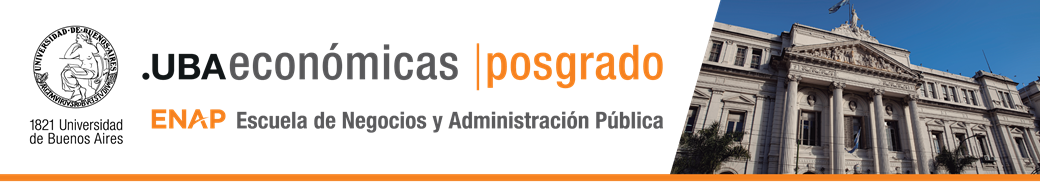

# **Metodologías Avanzados de Aprendizaje Automático**
# TP3 - REDES GENERATIVAS

**Docentes: Roberto Abalde, Mónica Cantoni**

**Alumno: Facundo Matías Blanco**


## Dataset: IBM HR Employee Attrition

**Objetivo:** Comparar el desempeño de un modelo de random forest con tres escenarios:
1. Datos originales (desbalanceados)
2. Datos balanceados con **SMOTE**
3. Datos balanceados con una **GAN tabular**

**Métricas:** F1-score, Precision y Recall sobre la clase minoritaria (Attrition = Yes)


## 0. Instalación de librerías

In [ ]:
                                                                        !pip install -U -q imbalanced-learn

## 1. Imports

In [ ]:
import tensorflow as tf
from tensorflow import keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import sklearn as sk
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

import imblearn as im
from imblearn.over_sampling import SMOTE

from tqdm.auto import trange

import os
import kagglehub

import warnings
warnings.filterwarnings('ignore')

## 2. Carga del dataset

In [ ]:
path = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [ ]:
df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-HR-Employee-Attrition.csv'))
df = df.sample(frac=1.0).reset_index(drop=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,48,Yes,Travel_Rarely,626,Research & Development,1,2,Life Sciences,1,64,...,4,80,0,23,2,3,1,0,0,0
1,55,No,Travel_Rarely,478,Research & Development,2,3,Medical,1,1770,...,2,80,3,34,2,3,1,0,0,0
2,47,No,Travel_Rarely,1225,Sales,2,4,Life Sciences,1,1676,...,3,80,3,29,2,3,3,2,1,2
3,40,No,Travel_Rarely,884,Research & Development,15,3,Life Sciences,1,1628,...,4,80,2,18,2,3,18,15,14,12
4,54,No,Travel_Rarely,1147,Sales,3,3,Marketing,1,303,...,4,80,1,16,4,3,6,2,0,5


In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


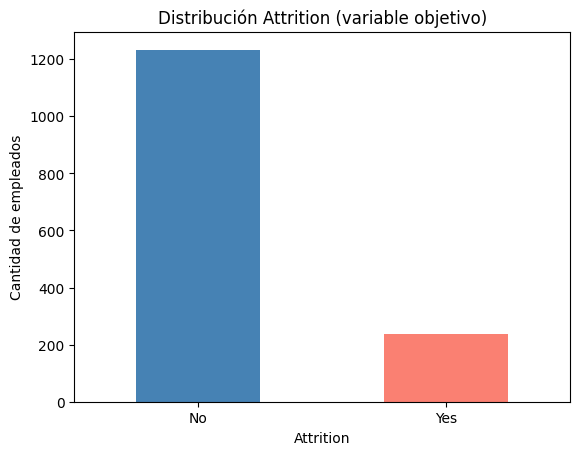

In [ ]:
df['Attrition'].value_counts().plot(
    kind='bar', color=['steelblue', 'salmon'],
    title='Distribución Attrition (variable objetivo)'
)
plt.xticks(rotation=0)
plt.ylabel('Cantidad de empleados')
plt.show()

## 3. Preprocesamiento

In [ ]:
# Eliminar columnas constantes que no aportan información
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'],
        errors='ignore', inplace=True)

# Dummies
df = pd.get_dummies(df, drop_first=True)

# Convertir booleanos a enteros antes de normalizar
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

# Normalizamos entre 0,1
df = (df - df.min()) / (df.max() - df.min())

df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.714286,0.375089,0.000000,0.25,0.000000,0.971429,0.333333,0.50,0.666667,0.230226,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.880952,0.269148,0.035714,0.50,0.666667,0.428571,0.333333,1.00,0.000000,0.949394,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.690476,0.803865,0.035714,0.75,0.333333,0.242857,1.000000,0.75,0.333333,0.787941,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.523810,0.559771,0.500000,0.50,0.000000,0.714286,0.333333,0.50,0.666667,0.496367,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.857143,0.748031,0.071429,0.50,1.000000,0.314286,0.666667,0.25,0.000000,0.259663,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
X = df.drop('Attrition_Yes', axis=1)
y = df['Attrition_Yes'].astype(int)

print(y.value_counts())

Attrition_Yes
0    1233
1     237
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train: {dict(y_train.value_counts())}')
print(f'Test:  {dict(y_test.value_counts())}')

Train: (1176, 44) | Test: (294, 44)
Train: {0: np.int64(986), 1: np.int64(190)}
Test:  {0: np.int64(247), 1: np.int64(47)}


## 4. Escenario 1 — Datos originales (sin balanceo)

In [ ]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_original = clf.predict(X_test)

print('precision:', sk.metrics.precision_score(y_test, y_pred_original))
print('recall:   ', sk.metrics.recall_score(y_test, y_pred_original))
print('f1:       ', sk.metrics.f1_score(y_test, y_pred_original))
print()
print(classification_report(y_test, y_pred_original, target_names=['No (0)', 'Yes (1)']))

precision: 0.75
recall:    0.1276595744680851
f1:        0.21818181818181817

              precision    recall  f1-score   support

      No (0)       0.86      0.99      0.92       247
     Yes (1)       0.75      0.13      0.22        47

    accuracy                           0.85       294
   macro avg       0.80      0.56      0.57       294
weighted avg       0.84      0.85      0.81       294



## 5. Escenario 2 — Balanceo con SMOTE

SMOTE (Synthetic Minority Oversampling Technique): selecciona dos ejemplos cercanos de la clase minoritaria, traza una línea entre ellos y crea un nuevo registro en un punto sobre esa línea.

In [ ]:
smote = im.over_sampling.SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(Counter(y_train_smote))

Counter({0: 986, 1: 986})


In [ ]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_smote, y_train_smote)
y_pred_smote = clf.predict(X_test)

print('precision:', sk.metrics.precision_score(y_test, y_pred_smote))
print('recall:   ', sk.metrics.recall_score(y_test, y_pred_smote))
print('f1:       ', sk.metrics.f1_score(y_test, y_pred_smote))
print()
print(classification_report(y_test, y_pred_smote, target_names=['No (0)', 'Yes (1)']))

precision: 0.7647058823529411
recall:    0.2765957446808511
f1:        0.40625

              precision    recall  f1-score   support

      No (0)       0.88      0.98      0.93       247
     Yes (1)       0.76      0.28      0.41        47

    accuracy                           0.87       294
   macro avg       0.82      0.63      0.67       294
weighted avg       0.86      0.87      0.84       294



## 6. Escenario 3 — Balanceo con GAN tabular

La GAN se entrena **solo con los registros de la clase minoritaria** (Attrition=Yes).

### Datos — solo clase minoritaria

In [ ]:
# Tomamos solo los registros de Attrition=Yes del train
# Ya están normalizados entre 0 y 1 desde el preprocesamiento
df_minority = X_train[y_train == 1].copy()
df_minority = df_minority.sample(frac=1.0).reset_index(drop=True)
print(f'Registros clase minoritaria en train: {len(df_minority)}')
df_minority.head()

Registros clase minoritaria en train: 190


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.333333,0.097351,0.142857,0.25,0.000000,0.242857,1.000000,0.00,0.666667,0.074934,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,0.357143,0.697208,0.071429,0.50,0.000000,0.571429,0.666667,0.00,0.000000,0.123170,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2,0.595238,0.504653,0.571429,0.50,0.666667,0.114286,0.333333,0.00,0.666667,0.075197,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,0.738095,0.982820,0.964286,0.25,0.000000,0.957143,0.333333,0.25,0.000000,0.172459,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.023810,0.226915,0.714286,0.50,1.000000,0.100000,0.333333,0.00,0.333333,0.058557,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


### Generador

In [ ]:
DIM_RUIDO = 10  # hiperparámetro a optimizar

modelo_generador = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[DIM_RUIDO]),

    keras.layers.Dense(128, activation='sigmoid'),


    # Capa de salida: cantidad de columnas del df
    keras.layers.Dense(df_minority.shape[1], activation='sigmoid')
])

modelo_generador.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 44)             │         5,676 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,084 (27.67 KB)

 Trainable params: 7,084 (27.67 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Probamos el modelo_generador
ruido = tf.random.normal((1, DIM_RUIDO))
fila_generada = modelo_generador(ruido, training=False)
fila_generada

<tf.Tensor: shape=(1, 44), dtype=float32, numpy=
array([[0.53622234, 0.37600198, 0.42532763, 0.5366654 , 0.24067625,
        0.5341821 , 0.35120556, 0.42630833, 0.59872144, 0.36046076,
        0.75387067, 0.6081707 , 0.57372755, 0.79184014, 0.38834393,
        0.5629078 , 0.69743806, 0.30086514, 0.5941355 , 0.6377499 ,
        0.41254935, 0.2456736 , 0.41898826, 0.30853352, 0.545314  ,
        0.2853396 , 0.6338224 , 0.5055821 , 0.5714458 , 0.49352962,
        0.6469119 , 0.5613193 , 0.6240983 , 0.6939501 , 0.49021986,
        0.49240202, 0.26169172, 0.3925136 , 0.55942535, 0.43564633,
        0.47398624, 0.38360417, 0.42590082, 0.4100102 ]], dtype=float32)>

### Discriminador

In [ ]:
modelo_discriminador = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[df_minority.shape[1]]),

    keras.layers.Dense(128, activation='sigmoid'),

    keras.layers.Dense(1, activation='sigmoid')
])

modelo_discriminador.compile(loss='binary_crossentropy', optimizer='adam')
modelo_discriminador.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Un valor cercano a 0.5 significa que no puede saber si es 0 o 1
modelo_discriminador(fila_generada)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.6004046]], dtype=float32)>

### Modelo adversario

In [ ]:
# Vamos a entrenar el discriminador a mano
modelo_discriminador.trainable = False

modelo_gan = keras.models.Sequential([
    modelo_generador,
    modelo_discriminador
])

modelo_gan.compile(loss='binary_crossentropy', optimizer='adam')

### Entrenamiento del modelo adversario

In [ ]:
# Entrenamos el generador y el discriminador
EPOCHS = 300
BATCH_SIZE = 32

for epoch in trange(EPOCHS, desc='epoch'):
    with trange(df_minority.shape[0] // BATCH_SIZE, desc='batch', leave=False) as t_batch:
        for n_batch in t_batch:
            ## Entrenamiento del modelo discriminador

            # seleccionamos BATCH_SIZE // 2 registros reales
            X_real = df_minority.values[np.random.randint(0, df_minority.shape[0], BATCH_SIZE // 2)]
            # creamos etiquetas para los registros reales (todas 1)
            y_real = np.ones((BATCH_SIZE // 2, 1)) * 0.9  # label smoothing

            # generamos BATCH_SIZE // 2 registros ficticios con el generador
            X_fake = modelo_generador(np.random.randn(DIM_RUIDO * BATCH_SIZE // 2).reshape(BATCH_SIZE // 2, DIM_RUIDO))
            # creamos etiquetas para los registros ficticios (todas 0)
            y_fake = np.zeros((BATCH_SIZE // 2, 1))

            # creamos un conjunto de entrenamiento para el discriminador
            X_train_disc = np.concatenate((X_real, X_fake))
            y_train_disc = np.concatenate((y_real, y_fake))

            # actualizamos los pesos del modelo discriminador
            modelo_discriminador.trainable = True
            discriminador_loss = modelo_discriminador.train_on_batch(X_train_disc, y_train_disc)
            modelo_discriminador.trainable = False

            ## Entrenamiento del modelo

            # generamos un lote de ruido
            X_gan = np.random.randn(DIM_RUIDO * BATCH_SIZE).reshape(BATCH_SIZE, DIM_RUIDO)

            # creamos etiquetas invertidas para los ejemplos ficticios (todas 1)
            y_gan = np.ones((BATCH_SIZE, 1))

            # actualizamos el generador usando el error del discriminador
            gan_loss = modelo_gan.train_on_batch(X_gan, y_gan)

            t_batch.set_postfix(discriminador_loss=f'{discriminador_loss:.3f}', gan_loss=f'{gan_loss:.3f}')

# mostramos las funciones de pérdida finales
print(discriminador_loss, gan_loss)
print('(discriminador_loss cercano a 0.5 indica equilibrio)')

epoch:   0%|          | 0/300 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

...

batch:   0%|          | 0/5 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

batch:   0%|          | 0/5 [00:00<?, ?it/s]

0.4734156 1.4389167
(discriminador_loss cercano a 0.5 indica equilibrio)


### Generación de registros sintéticos para balancear

In [ ]:
# Calculamos cuántos registros necesitamos para balancear
n_mayoritaria = int((y_train == 0).sum())
n_minoritaria = int((y_train == 1).sum())
n_generar = n_mayoritaria - n_minoritaria

print(Counter(y_train))
print(f'Registros a generar: {n_generar}')

# generamos registros ficticios con el generador
X_fake = modelo_generador(np.random.randn(DIM_RUIDO * n_generar).reshape(n_generar, DIM_RUIDO))
print(X_fake)

Counter({0: 986, 1: 190})
Registros a generar: 796
tf.Tensor(
[[4.07986529e-02 1.41914025e-01 2.79149823e-02 ... 1.12572350e-01
  9.14064050e-01 9.14162695e-01]
 [2.37804856e-02 1.87786266e-01 3.47322002e-02 ... 1.13642186e-01
  9.25262809e-01 9.13336098e-01]
 [3.50635091e-04 1.55620398e-02 2.10332015e-04 ... 6.92085735e-03
  9.97632325e-01 9.97866452e-01]
 ...
 [4.58569713e-02 1.62003934e-01 3.71829160e-02 ... 1.11949764e-01
  8.81625414e-01 8.91248286e-01]
 [1.84015383e-03 3.09567917e-02 1.39143993e-03 ... 1.32808592e-02
  9.91587758e-01 9.93649006e-01]
 [9.68986191e-03 7.02276528e-02 8.36342853e-03 ... 3.32024321e-02
  9.65626955e-01 9.75774229e-01]], shape=(796, 44), dtype=float32)


In [ ]:
# Pasamos a DataFrame y redondeamos columnas binarias (deben ser 0 o 1)
X_sint_df = pd.DataFrame(X_fake.numpy(), columns=df_minority.columns)

cols_bool = [c for c in X_sint_df.columns if X_train[c].nunique() == 2]
X_sint_df[cols_bool] = X_sint_df[cols_bool].round()

#Redondeo de valores
umbral = 0.2
for col in X_sint_df.columns:
    X_sint_df[col] = X_sint_df[col].apply(
        lambda x: 1.0 if x >= (1 - umbral) else (0.0 if x <= umbral else x)
    )

print(X_sint_df.head())

   Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.0        0.0               0.0        1.0                      0.0   
1  0.0        0.0               0.0        1.0                      0.0   
2  0.0        0.0               0.0        1.0                      0.0   
3  0.0        0.0               0.0        1.0                      0.0   
4  0.0        0.0               0.0        1.0                      0.0   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    0.677307             1.0       0.0              0.0            0.0  ...   
1    0.789904             1.0       0.0              0.0            0.0  ...   
2    1.000000             1.0       0.0              0.0            0.0  ...   
3    1.000000             1.0       0.0              0.0            0.0  ...   
4    0.715403             1.0       0.0              0.0            0.0  ...   

   JobRole_Laboratory Technician  JobRole_Manager  \
0              

In [ ]:
# Combinamos el train original con los registros sintéticos
y_sint = pd.Series([1] * n_generar)

X_train_gan = pd.concat([X_train, X_sint_df], ignore_index=True)
y_train_gan = pd.concat([y_train.reset_index(drop=True), y_sint], ignore_index=True)

print(Counter(y_train_gan))

Counter({0: 986, 1: 986})


In [ ]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_gan, y_train_gan)
y_pred_gan = clf.predict(X_test)

print('precision:', sk.metrics.precision_score(y_test, y_pred_gan))
print('recall:   ', sk.metrics.recall_score(y_test, y_pred_gan))
print('f1:       ', sk.metrics.f1_score(y_test, y_pred_gan))
print()
print(classification_report(y_test, y_pred_gan, target_names=['No (0)', 'Yes (1)']))

precision: 0.8
recall:    0.1702127659574468
f1:        0.2807017543859649

              precision    recall  f1-score   support

      No (0)       0.86      0.99      0.92       247
     Yes (1)       0.80      0.17      0.28        47

    accuracy                           0.86       294
   macro avg       0.83      0.58      0.60       294
weighted avg       0.85      0.86      0.82       294



## 7. Comparativa final

In [ ]:
resultados = {
    'Escenario': ['Original', 'SMOTE', 'GAN'],
    'Precision': [precision_score(y_test, y_pred_original),
                  precision_score(y_test, y_pred_smote),
                  precision_score(y_test, y_pred_gan)],
    'Recall':    [recall_score(y_test, y_pred_original),
                  recall_score(y_test, y_pred_smote),
                  recall_score(y_test, y_pred_gan)],
    'F1':        [f1_score(y_test, y_pred_original),
                  f1_score(y_test, y_pred_smote),
                  f1_score(y_test, y_pred_gan)]
}

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

Escenario  Precision   Recall       F1
 Original   0.750000 0.127660 0.218182
    SMOTE   0.764706 0.276596 0.406250
      GAN   0.800000 0.170213 0.280702


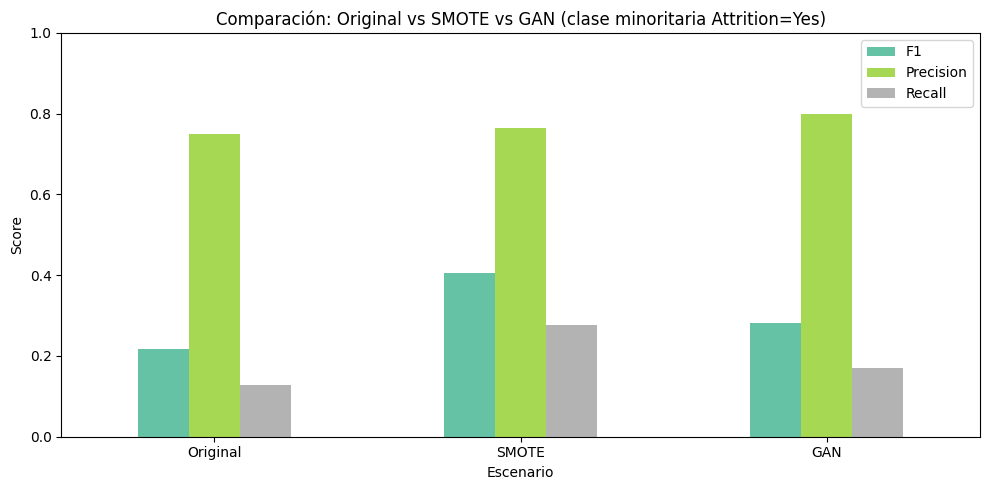

In [ ]:
df_resultados.set_index('Escenario')[['F1', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=0, colormap='Set2'
)
plt.title('Comparación: Original vs SMOTE vs GAN (clase minoritaria Attrition=Yes)')
plt.ylabel('Score')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Mejores resultados
| Escenario              | Precision | Recall | F1-score |
| ---------------------- | --------: | -----: | -------: |
| Random Forest original |      0.75 |   0.13 |     0.22 |
| SMOTE                  |      0.77 |   0.36 |     0.49 |
| GAN            |      0.91 |   0.21 |     0.34 |


Dado que SMOTE y la GAN incorporan componentes aleatorios, las métricas pueden variar entre corridas cuando no se fija completamente la semilla de todos los procesos involucrados. Por ese motivo, además de la corrida visible en el notebook, se reportan los mejores resultados obtenidos para cada escenario durante la experimentación.